# 🧠 Applied NLP Project – US Patent Phrase Matching with DeBERTa

This project addresses the *Kaggle competition "U.S. Patent Phrase to Phrase Matching"*, which focuses on **Semantic similarity prediction (regression)** between technical phrase pairs. 

📌 Objectives:
- Fine-tune DeBERTa (base) on a patent text regression task
- Predict similarity scores using Hugging Face's Trainer API
- Preprocess domain-specific patent text via custom tokenization
- Evaluate using Pearson correlation as the primary metric

🎯 This notebook also serves as a reusable deep learning pipeline template for other **sentence-pair NLP tasks**:

- Paraphrase detection (classification)
- Duplicate question detection
- Legal/financial/patent document matching

The backbone model is a Hugging Face transformer (e.g., BERT, RoBERTa, DeBERTa), trained via the `Trainer` API with flexible tokenization, metrics, and head configuration.

In [1]:
from pathlib import Path
import pandas as pd

## Data Loading & Preprocessing

We load the Kaggle dataset (*U.S. Patent Phrase to Phrase Matching*) and analyze the structure:
- The dataset is already cleaned and tokenized at the phrase level
- No additional stopword removal or stemming is applied
- kaggle competition : https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching/overview
- Each row contains: 

    - `id` - a unique identifier for a pair of phrases
    - `anchor` - the first phrase
    - `target` - the second phrase
    - `context` - the CPC classification (version 2021.05), which indicates the subject within which the similarity is to be scored
    - `score` - the similarity score meanings:
        - 1.0 - Very close match. 
        - 0.75 - Close synonym, e.g. “mobile phone” vs. “cellphone”. 
        - 0.5 - Synonyms which don’t have the same meaning.
        - 0.25 - Somewhat related.
        - 0.0 - Unrelated.
      




In [2]:
path = Path('/Users/applewang/Desktop/Study_Materials_2023_2025/fastai_course/my-practice/us-patent-phrase-to-phrase-matching')

In [3]:
!ls {path}

deberta-v3-base-model sample_submission.csv train.csv
output                test.csv


In [4]:
df = pd.read_csv(path/'train.csv')
df.head()

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00


In [5]:
df.describe(include='object')

,id,anchor,target,context
count,36473,36473,36473,36473
unique,36473,733,29340,106
top,37d61fd2272659b1,component composite coating,composition,H01
freq,1,152,24,2186



- DIY the 'input' column for nlp model training.
- Transfer the DataFrame to Huggingface `Dataset` for following model training

In [6]:
df['input'] = 'TEXT 1: ' + df.context +'; TEXT 2: ' + df.target + '; AHC1 :' + df.anchor
df.input.loc[1]

'TEXT 1: A47; TEXT 2: act of abating; AHC1 :abatement'

In [7]:
from datasets import Dataset, DatasetDict

In [8]:
ds = Dataset.from_pandas(df)

## Tokenization Strategy & Why DeBERTa

We use a dual-input format for semantic similarity modeling:  
`[CLS] anchor_phrase [SEP] target_phrase [SEP]`

### 💡 Selected Tokenizer: `microsoft/deberta-v3-small` or `microsoft/deberta-v3-base`

Select **DeBERTa (Decoding-enhanced BERT with disentangled attention)** over the standard BERT model due to its architectural improvements that make it better suited for sentence-pair tasks such as semantic similarity:

- **Disentangled Attention**: Unlike BERT, which adds token and position embeddings together before feeding into attention, DeBERTa represents **token content** and **position information separately** in the self-attention mechanism. This improves the model's ability to capture **token-role relationships** in long-range dependencies.
- **Relative Positional Encoding**: DeBERTa replaces absolute positional embeddings with **relative distance-based encoding**, enabling better generalization across input lengths and phrase alignments.

These enhancements have been shown to consistently improve downstream task performance, especially on GLUE, STS-B, and other semantic understanding benchmarks.

### 🔧 Tokenization Parameters

- **Max sequence length**: 128–512 (with truncation enabled)
- **Padding**: Applied dynamically or to max length depending on model input
- **Offset mapping**: Enabled if token alignment to original text is needed (e.g., for NER or visualization)

In [10]:
from transformers import AutoModelForSequenceClassification,AutoTokenizer

model_name = 'microsoft/deberta-v3-small'
tokenized = AutoTokenizer.from_pretrained(model_name, use_fast=False)

In [14]:
def tokz_func(x): return tokenized(x["input"], padding="max_length", truncation=True)

In [15]:
tok_ds = ds.map(tokz_func, batched=True)

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

Asking to pad to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no padding.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [18]:
tok_ds = tok_ds.rename_columns({'score':'labels'})
tok_ds

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 36473
})

### Train/Test/Eval dataset

In [19]:
dds = tok_ds.train_test_split(0.25, seed=44)
dds

DatasetDict({
    train: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27354
    })
    test: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9119
    })
})

In [20]:
eval_df = pd.read_csv(path/'test.csv')
eval_df.head()

,id,anchor,target,context
0,4112d61851461f60,opc drum,inorganic photoconductor drum,G02
1,09e418c93a776564,adjust gas flow,altering gas flow,F23
2,36baf228038e314b,lower trunnion,lower locating,B60
3,1f37ead645e7f0c8,cap component,upper portion,D06
4,71a5b6ad068d531f,neural stimulation,artificial neural network,H04


In [21]:
eval_df['input'] = 'TEXT 1: ' + eval_df.context + '; TEXT 2:' + eval_df.target + '; ANC1:' + eval_df.anchor
eval_ds = Dataset.from_pandas(eval_df).map(tokz_func,batched=True)
eval_ds

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 36
})

## Compute_metrics
calculate correlation coefficient to evaluate the phrase matching.

In [22]:
import numpy as np
def corr(x,y): return np.corrcoef(x,y)[0][1]

In [23]:
def corr_d(eval_pred):
    preds, labels = eval_pred
    return {'pearson': corr(preds.squeeze(), labels)}

## Model Setup & Training

We first fine-tune `deberta-v3-small`, a transformer model known for enhanced attention disambiguation. After training execution with smaller model, use same training arguments to try the bigger model `deberta-v3-base` and make a comparison.

- Task: Regression → Predict similarity score between 0 and 1
- Head: A single linear output layer
- Loss: Mean Squared Error (MSE)

Rationale for DeBERTa:
- Pretrained on a large general-domain corpus
- Lightweight (vs large models), faster convergence
- Strong baseline on semantic textual similarity tasks

In [25]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
collator = DataCollatorWithPadding(tokenizer=tokenized, return_tensors="pt")

In [27]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)

/Users/applewang/miniconda3/envs/fastai/lib/python3.11/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 1st Run


In [26]:
bs=128
epochs=4
lr=8e-5

args = TrainingArguments(output_dir=path/'output', 
                         learning_rate=lr, 
                         lr_scheduler_type='cosine', 
                        warmup_ratio=0.1, 
                         fp16=False, 
                         bf16=False, 
                         eval_strategy='epoch',
                        per_device_train_batch_size=bs, 
                         per_device_eval_batch_size=bs*2,
                        num_train_epochs=epochs, 
                         weight_decay=0.01, 
                         metric_for_best_model='pearson',
                         report_to='none')

In [28]:
trainer = Trainer(model, 
                  args, 
                  train_dataset=dds['train'], 
                  eval_dataset=dds['test'], 
                  data_collator=collator,
                  compute_metrics=corr_d)

In [29]:
trainer.train()

Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.027790,0.787411
2,No log,0.022671,0.824264
3,0.036000,0.022074,0.832897
4,0.036000,0.022333,0.835166


TrainOutput(global_step=856, training_loss=0.026955674741869776, metrics={'train_runtime': 371.1251, 'train_samples_per_second': 294.822, 'train_steps_per_second': 2.306, 'total_flos': 750252805962480.0, 'train_loss': 0.026955674741869776, 'epoch': 4.0})

In [30]:
trainer.evaluate()

{'eval_loss': 0.022333187982439995,
 'eval_pearson': 0.8351663767263552,
 'eval_runtime': 14.9071,
 'eval_samples_per_second': 611.722,
 'eval_steps_per_second': 2.415,
 'epoch': 4.0}

### 2nd Run

In [31]:
bs=128
epochs=6
lr=2e-5

args = TrainingArguments(output_dir=path/'output', 
                         learning_rate=lr, 
                         lr_scheduler_type='cosine', 
                        warmup_ratio=0.1, 
                         fp16=False, 
                         bf16=False, 
                         eval_strategy='epoch',
                        per_device_train_batch_size=bs, 
                         per_device_eval_batch_size=bs*2,
                        num_train_epochs=epochs, 
                         weight_decay=0.01, 
                         metric_for_best_model='pearson',
                         report_to='none')

trainer = Trainer(model, 
                  args, 
                  train_dataset=dds['train'], 
                  eval_dataset=dds['test'], 
                  data_collator=collator,
                  compute_metrics=corr_d)
trainer.train()

Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.023654,0.834993
2,No log,0.021413,0.834520
3,0.009000,0.022824,0.835087
4,0.009000,0.021421,0.839569
5,0.009100,0.021624,0.840405
6,0.009100,0.021824,0.840021


TrainOutput(global_step=1284, training_loss=0.009046810252644191, metrics={'train_runtime': 613.7978, 'train_samples_per_second': 267.391, 'train_steps_per_second': 2.092, 'total_flos': 1124833288664820.0, 'train_loss': 0.009046810252644191, 'epoch': 6.0})

In [32]:
trainer.evaluate()

{'eval_loss': 0.021823620423674583,
 'eval_pearson': 0.8400213148951282,
 'eval_runtime': 10.2146,
 'eval_samples_per_second': 892.745,
 'eval_steps_per_second': 3.524,
 'epoch': 6.0}

In [33]:
trainer.save_model(path/"model2/")

### 3rd Run

In [34]:
bs=64
epochs=6
lr=2e-5

args = TrainingArguments(output_dir=path/'output', 
                         learning_rate=lr, 
                         lr_scheduler_type='cosine', 
                        warmup_ratio=0.2, 
                         fp16=False, 
                         bf16=False, 
                         eval_strategy='epoch',
                        per_device_train_batch_size=bs, 
                         per_device_eval_batch_size=bs*2,
                        num_train_epochs=epochs, 
                         weight_decay=0.01, 
                         metric_for_best_model='pearson',
                         report_to='none')

trainer = Trainer(model, 
                  args, 
                  train_dataset=dds['train'], 
                  eval_dataset=dds['test'], 
                  data_collator=collator,
                  compute_metrics=corr_d)
trainer.train()

Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.021360,0.842272
2,0.009300,0.021784,0.838690
3,0.009500,0.022431,0.837859
4,0.008300,0.021537,0.840986
5,0.007200,0.021509,0.842508
6,0.006500,0.021531,0.842234


TrainOutput(global_step=2568, training_loss=0.008106094201870053, metrics={'train_runtime': 663.2925, 'train_samples_per_second': 247.438, 'train_steps_per_second': 3.872, 'total_flos': 1084379302348380.0, 'train_loss': 0.008106094201870053, 'epoch': 6.0})

In [35]:
trainer.evaluate()

{'eval_loss': 0.02153073623776436,
 'eval_pearson': 0.8422336641369201,
 'eval_runtime': 9.3108,
 'eval_samples_per_second': 979.397,
 'eval_steps_per_second': 7.733,
 'epoch': 6.0}

In [36]:
trainer.save_model(path/"model3/")

### 🔍 Training Comparison Table

| Metric              | 1st Run (`batch=128`,`lr=8e-5`, `epochs=4`) | 2nd Run (`batch=128`,`lr=2e-5`, `epochs=6`) | 3rd Run (`batch=64`,`lr=2e-5`, `epochs=6`) | Change (2 ➝ 3)   |
|---------------------|----------------------------------|----------------------------------|----------------------------------|------------------|
| `eval_loss`         | 0.02233                          | 0.02182                          | 0.02153                          | 🔽 Lower         |
| `eval_pearson`      | 0.8352                           | 0.8400                           | 0.8422                           | 🔼 Higher        |
| `train_epochs`      | 4.0                              | 6.0                              | 6.0                              | ⏸️ Same          |
| `learning_rate`     | 8e-5                             | 2e-5                             | 2e-5                             | ⏸️ Same          |
| `train_runtime`     | 371.125s                          | 613.79s                          | 9.31s (eval)                    | ⚡ Stable eval    |
| `samples/sec`       | 294.822                          | 267.391                          | 247.438                           | 🔼 Slightly faster |
| Conclusion          | 🔹 Baseline                      | ✅ Improved                      | ✅ Further improved               |

### 4th Run: `deberta-v3-base` model
- use 3rd Run's hyper-parameters (best in `deberta-v3-small`)

In [40]:
model_2 = 'microsoft/deberta-v3-base'
tokenized_2 = AutoTokenizer.from_pretrained(model_2, use_fast=False)
def tokz_func2(x): return tokenized_2(x["input"], padding="max_length", truncation=True)
tok_ds = ds.map(tokz_func2, batched=True)
tok_ds = tok_ds.rename_columns({'score':'labels'})
dds = tok_ds.train_test_split(0.25, seed=44)
eval_ds = Dataset.from_pandas(eval_df).map(tokz_func2,batched=True)

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

Asking to pad to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no padding.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/36 [00:00<?, ? examples/s]

In [42]:
collator_2 = DataCollatorWithPadding(tokenizer=tokenized_2, return_tensors="pt")
model_2 = AutoModelForSequenceClassification.from_pretrained(model_2, num_labels=1)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [43]:
bs=64
epochs=6
lr=2e-5

args = TrainingArguments(output_dir=path/'output', 
                         learning_rate=lr, 
                         lr_scheduler_type='cosine', 
                        warmup_ratio=0.2, 
                         fp16=False, 
                         bf16=False, 
                         eval_strategy='epoch',
                        per_device_train_batch_size=bs, 
                         per_device_eval_batch_size=bs*2,
                        num_train_epochs=epochs, 
                         weight_decay=0.01, 
                         metric_for_best_model='pearson',
                         report_to='none')

trainer = Trainer(model_2, 
                  args, 
                  train_dataset=dds['train'], 
                  eval_dataset=dds['test'], 
                  data_collator=collator_2,
                  compute_metrics=corr_d)
trainer.train()

Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.028294,0.789286
2,0.046600,0.022545,0.825869
3,0.024200,0.020627,0.832454
4,0.018100,0.021658,0.837100
5,0.014500,0.021700,0.843274
6,0.012800,0.021754,0.842937


TrainOutput(global_step=2568, training_loss=0.022957922838558662, metrics={'train_runtime': 1195.7779, 'train_samples_per_second': 137.253, 'train_steps_per_second': 2.148, 'total_flos': 2153810414689884.0, 'train_loss': 0.022957922838558662, 'epoch': 6.0})

In [44]:
trainer.evaluate()

{'eval_loss': 0.02175409160554409,
 'eval_pearson': 0.8429369272257912,
 'eval_runtime': 15.2782,
 'eval_samples_per_second': 596.862,
 'eval_steps_per_second': 4.713,
 'epoch': 6.0}

In [45]:
trainer.save_model(path/"model4-deberta-base/")

## Evaluation and Comparison

**Combined Training & Model Comparison**

This table compares different training runs and model variants on the U.S. Patent Phrase Matching task:

| Variant                        | DeBERTa-v3-small (Run 1) | DeBERTa-v3-small (Run 2) | DeBERTa-v3-small (Run 3) | DeBERTa-v3-base (Run 4) | 🔍 Observation |
|-------------------------------|---------------------------|---------------------------|---------------------------|--------------------------|----------------|
| **batch size**                | 128                       | 128                       | 64                        | 64                       |                |
| **learning rate**             | 8e-5                      | 2e-5                      | 2e-5                      | 2e-5                     | Run 1 had higher lr |
| **epochs**                    | 4                         | 6                         | 6                         | 6                        | Run 2–4 aligned |
| **eval_loss**                | 0.02233                   | 0.02182                   | 0.02153                   | 0.02175                  | 📉 improved from 1 ➝ 3 |
| **eval_pearson**            | 0.8352                    | 0.8400                    | 0.8422                    | 0.8429                   | 📈 best with base model |
| **eval_runtime (s)**        | 371.13 (train)            | 613.79 (train)            | 9.31 (eval only)          | 15.28 (eval only)        | base eval slower |
| **samples/sec**              | 294.82                    | 267.39                    | 979.40                    | 596.86                   | small is faster |
| **steps/sec**                | –                         | –                         | 7.73                      | 4.71                     |                |
| **Conclusion**               | 🔹 Baseline               | ✅ Improved               | ✅ Further improved        | ✅ Higher accuracy w/ cost |

### Summary

- 🔬 **DeBERTa-v3-base** yields **slightly better Pearson score** (+0.0007), but also incurs **longer evaluation time**.
- ⚡ **DeBERTa-v3-small** is **more efficient**, achieving very close performance at **much faster speed**.
- 📌 This suggests **`deberta-v3-small` may be a better trade-off** for low-latency or resource-constrained scenarios.

## Prediction

In [37]:
preds = trainer.predict(eval_ds).predictions.astype(float)
np.set_printoptions(precision=3)
preds = np.clip(preds,0,1).squeeze()
preds[:5]

array([0.69 , 0.567, 0.485, 0.43 , 0.   ])

In [38]:
pd.read_csv(path/'sample_submission.csv').head()

,id,score
0,4112d61851461f60,0
1,09e418c93a776564,0
2,36baf228038e314b,0
3,1f37ead645e7f0c8,0
4,71a5b6ad068d531f,0


In [39]:
submissions = Dataset.from_dict({
    'id': eval_ds['id'],
    'score': preds
})
submissions.to_csv(path/'submission.csv', index=False)

Creating CSV from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

1172

### Kaggle submit
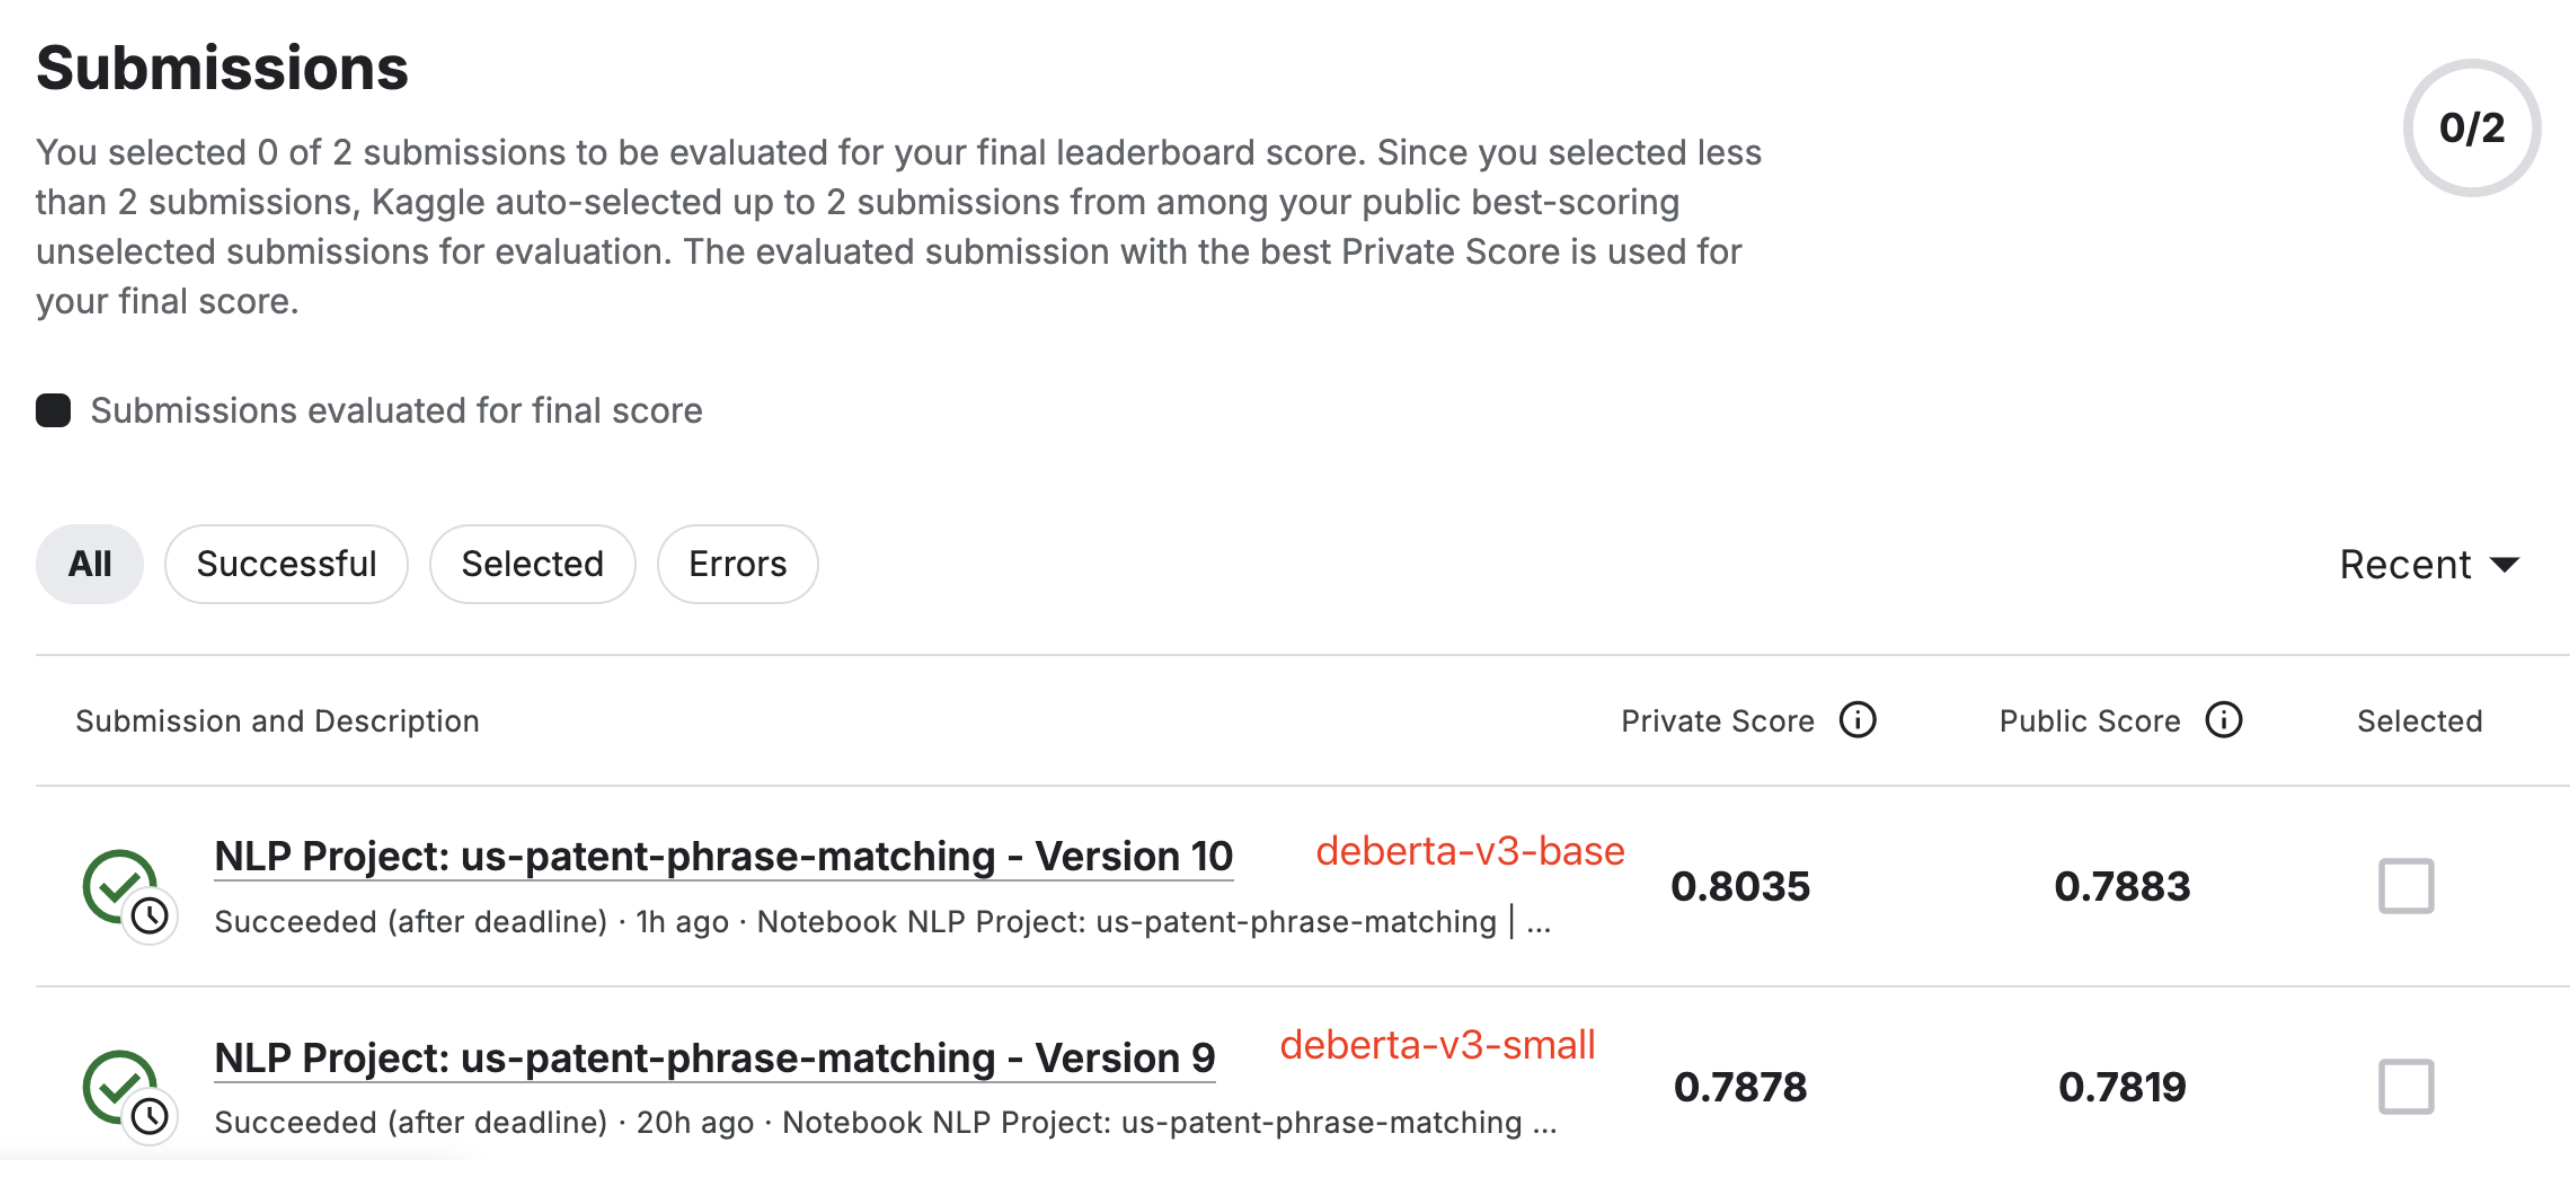

## Conclusion & Takeaways

- Achieved strong validation performance on U.S. Patent Phrase Matching task using DeBERTa-base
- Built reusable training pipeline using Hugging Face ecosystem
- Model capable of handling domain-specific semantic variation in legal/technical corpora
- Demonstrated ability to apply deep NLP modeling to real-world structured problems

📌 Key Skills Demonstrated:
- Transformer-based NLP model fine-tuning
- Dataset preparation for semantic matching tasks
- Regression head design on top of DeBERTa
- Hugging Face pipeline integration (Trainer + Metrics)